:meth:`SeqMutPlot.variant_impact` ranks the combined variants from :meth:`SeqMut.combine` as a horizontal bar chart, each bar the variant's ``delta_pred`` (model prediction shift) colored by sign.

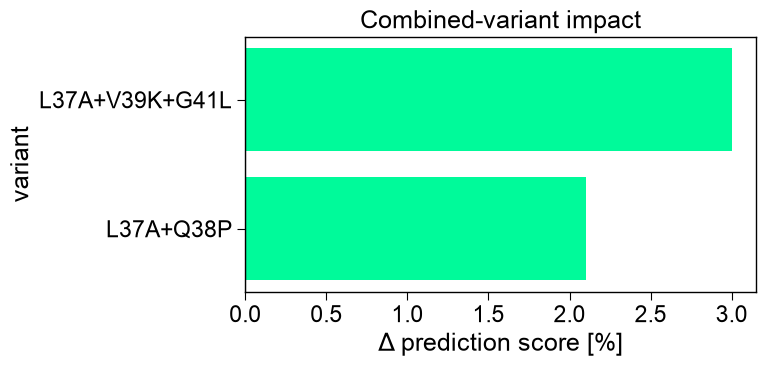

In [1]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False

# Data, CPP features, and a fitted TreeModel that scores each sequence
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = df_seq["label"].to_list()
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
split_kws = sf.get_split_kws()
df_scales = aa.load_scales()
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws, df_scales=df_scales, verbose=False)
df_feat = cpp.run(labels=labels, n_filter=25)
X = sf.feature_matrix(features=list(df_feat["feature"]), df_parts=df_parts, df_scales=df_scales)
tm = aa.TreeModel().fit(X, labels=labels)
entry = df_seq["entry"].iloc[0]
ts = int(df_seq.set_index("entry").loc[entry, "tmd_start"])

seqmut = aa.SeqMut(model=tm)
variants = pd.DataFrame({
    "entry": [entry] * 5,
    "variant": ["double", "double", "triple", "triple", "triple"],
    "pos": [ts, ts + 1, ts, ts + 2, ts + 4],
    "to_aa": ["A", "P", "A", "K", "L"],
})
df_variant = seqmut.combine(df_seq=df_seq, variants=variants, df_feat=df_feat)
aa.plot_settings()
aa.SeqMutPlot().variant_impact(df_variant=df_variant, entry=entry, n=10, figsize=(8, 4))
plt.tight_layout()
plt.show()